In [132]:
# Import necessary libraries
%load_ext autoreload
%autoreload 2

import sys
import os
import typing as tp
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
dtype = torch.float64
device = torch.device("cpu")

# 1. Set the samples.

We need three samples: singlet, triplet and their concatentation with block-diagonal stracture.

In [134]:
# Let's start from the singlet sample
g_tensor = spin_model.Interaction([2.00, 2.00, 2.00], dtype=dtype, device=device)

base_spin_system = spin_model.SpinSystem(
    electrons=[0.0],  # S=0 singlet
    g_tensors=[g_tensor],
    energy_shift=constants.unit_converter(0.1, "eV_to_Hz"),
    device=device,
    dtype=dtype,
)

singlet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    mesh=(20, 20),
    device=device,
    dtype=dtype,
)

# Let's set the triplet
g_tensor = spin_model.Interaction([2.00, 2.004, 2.007], dtype=dtype, device=device)
zfs_interaction = spin_model.DEInteraction([140e6, 40e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0],  # S=1 triplet
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)],
    device=device,
    dtype=dtype,
)

triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    mesh=(20, 20),
    device=device,
    dtype=dtype,
)

# Create concatenated sample
concated_sample = mars.concat((triplet, singlet))  # Triplet , then singlet order

# 2. Set the relaxation parameters

Here we set the relaxation parameters for each part of realxation pathways:
1) Singlet decay

2) Triplet decay

3) Intra-triplet relaxation

4) Singlet - triplet relaxation

### 2.1. Set the singlet decay and its population

In [135]:
context_singlet = population.Context(init_populations=[1.0], out_probs=[1e7], device=device, dtype=dtype) # We set the decay in 1e7 s^-1

# We do not nessusary need to set basis here

### 2.2. Set the triplet decay and its population

In [136]:
context_triplet_decay = population.Context(basis="xyz", sample=triplet, out_probs=[1e4, 1e4, 1e4], device=device, dtype=dtype)
# Herein we already need basis "xyz" and sample

### 2.3. Set the Intra-tiplet relaxation

We set it vai the Bloch-Redfield Formalism and appropriate Density function 

##### 2.3.1 Set the spectral denisty function

In [137]:
class SpectralDensity:
    """
    Calculates the Spectral Density function based on a set of mode frequencies 
    and temperature, utilizing a Lorentzian broadening model.
    """

    def __init__(self, w_k: tp.Union[float, torch.Tensor], temperature: tp.Union[float, torch.Tensor],
                 dtype: torch.dtype = torch.float32, device: torch.device=torch.device("cpu")):
        """
        Initialize the SpectralDensity calculator.

        :param w_k: Mode frequencies in inverse centimeters (cm^-1).
        :type w_k: torch.Tensor or array-like
        :param temperature: System temperature in Kelvin.
        :type temperature: float
        """
        super().__init__()
        w_k_hz = constants.unit_converter(w_k, "cm-1_to_Hz")
        self.w_k_rad = torch.tensor(w_k_hz, dtype=dtype, device=device) * (2 * math.pi)
        w_k_K = torch.tensor(constants.unit_converter(w_k, "cm-1_to_K"), dtype=dtype, device=device)
        exp_val = torch.exp(w_k_K / temperature)
        self._occup = 1.0 / torch.expm1(w_k_K / temperature)

        self._delta = torch.sqrt(self.w_k_rad ** 2 * exp_val * self._occup ** 2)

    def __call__(self, w_rad: tp.Union[torch.Tensor, float]) -> torch.Tensor:
        """
        Evaluate the spectral density at given probe frequencies.

        :param w_rad: Probe frequencies in radians per second (rad/s).
        :type w_rad: torch.Tensor or float
        :return: Spectral density values calculated at the probe frequencies.
        :rtype: torch.Tensor
        """
        plus = self.w_k_rad + w_rad
        minus = self.w_k_rad - w_rad
        term_plus = self._lorentz(plus) * self._occup
        term_minus = self._lorentz(minus) * (self._occup + 1.0)
        return term_plus + term_minus

    def _lorentz(self, arg: torch.Tensor) -> torch.Tensor:
        """
        Compute the Lorentzian lineshape function.

        :param arg: Frequency argument (typically sum or difference of frequencies).
        :type arg: torch.Tensor
        :return: Lorentzian value delta / (delta^2 + arg^2).
        :rtype: torch.Tensor
        """
        return self._delta / (self._delta ** 2 + arg ** 2)

    def __repr__(self) -> str:
        """
        Return a string representation of the object.

        :return: String containing class name and shape of mode frequencies.
        :rtype: str
        """
        return f"SpectralDensity(modes={self.w_k_rad.shape}, device={self.w_k_rad.device})"

##### 2.3.2 Get coupling operators

In the current consideration we get the coupling operators via the librations along x,y,z axes. Each libration happens with each own frequency.

In the general the final coupling operaotor in MarS is constructed from two parts:
 
- O_static: Field-independent operator. This is zero-field splitting and hyperfine interaction
- O_dependent: Field-dependent operator. This is zero-field Zeeman interaction

MarS can automatically extract it. Thay are mesured in Hz and Hz / T respectifully. We need to convert Hz into rad / s  

In [138]:
coupling_operators = []
for i in range(3):
    n = torch.zeros((3, ), dtype=dtype, device=device)
    n[i] = 1.0
    O_static, O_field = triplet.get_librations_along_axis(n)
    O_static = O_static * (2 * math.pi)
    O_field = O_field * (2 * math.pi)
    
    coupling_operators.append(
        (O_static, O_field)
    )

##### 2.3.3 Set final context

We set some temeprature, and the frequency for x,y,z equal to the 75, 100, 125 cm-1

In [139]:
temperature = torch.tensor(100.0, dtype=dtype, device=device)
frequencies = [75, 100, 125]
freq_res = 35 * 1e9

In [140]:
dtype = torch.float64
device = torch.device("cpu")

In [141]:
channels = []
for i, freq in enumerate(frequencies):
    spectral_density_func = SpectralDensity(freq, temperature, dtype, device)
    channels.append(
        population.RedfieldRelaxationChannel(operator_components=[coupling_operators[i]],
                                             spectral_density_func=spectral_density_func,
                                             thermal_balance_mode="skip")
    )
    
context_triplet_intra = population.Context(
    basis="product", sample=triplet,
    redfield_channels=channels, device=device, dtype=dtype
)

Let's make the sainty check and look on the values of relaxatino rates

In [142]:
fields = torch.tensor([0.3])
F, _, _, Gz = triplet.get_hamiltonian_terms()
H = F + Gz * fields
H  = H.unsqueeze(-3)
energies, full_system_vectors = torch.linalg.eigh(H)

# For the Redfield relaxation the driven probs return the rates, not free. It is supposed that thay shouldn't be modified futher
rates = context_triplet_intra.get_transformed_driven_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)

In [143]:
print(rates[0, 0])

tensor([[    0.0000, 43188.0103,  5935.5738],
        [43009.2071,     0.0000, 65432.4459],
        [ 5874.1299, 65146.9075,     0.0000]], dtype=torch.float64)


Rates are cloase to (4 - 6) * 10^4 With a little bit values for T1 - T0 and T-1 - T0 transitions

### 2.4. Set the rates between singlet and triplet sublevels

We have some little problem: we need to set relaxation between triplet "xyz" sublevels and singlet sublevel. The concatenated sample has 4-energy levels and xyz do not defined for it. To solve it, we
1) Set it in zero-field splitting basis
2) And match zero-field splitting levels with xyz levels.

In [144]:
import torch
import typing as tp

# Assuming these are available in the global scope
# from your_module import concated_sample, triplet

def get_triplet_singlet_rates(
    vector_xyz: tp.Union[list, tuple, torch.Tensor]
) -> torch.Tensor:
    """
    Construct a 4x4 symmetric relaxation rate matrix connecting triplet sublevels 
    to the singlet state in the zero-field splitting (ZFS) basis.
    
    This function maps the provided relaxation rates for the triplet sublevels 
    (Tx, Ty, Tz) to the corresponding transitions towards the Singlet state (S) 
    within the 4-level system. Since the ZFS basis may have a different ordering 
    than the xyz triplet basis, this function matches eigenvectors between the 
    two bases to ensure correct rate assignment.
    
    :param vector_xyz: list | tuple | torch.Tensor
        A vector containing the relaxation rates [k_x, k_y, k_z] corresponding 
        to the transitions between the triplet sublevels (Tx, Ty, Tz) and the 
        Singlet state (S). The order is [Tx→S, Ty→S, Tz→S] in the xyz basis.
        Values should be non-negative floats or tensors.
    
    :return: torch.Tensor
        A 4x4 symmetric matrix (torch.Tensor) representing the relaxation rates 
        in the ZFS basis. The matrix indices correspond to the ZFS eigenstates:
        - Indices 0, 1, 2: Triplet sublevels (matched to Tx, Ty, Tz)
        - Index 3: Singlet state (S)
        Off-diagonal elements are populated with the matched rates from 
        `vector_xyz`. The matrix is symmetric: rate[i, j] = rate[j, i].
    """
    rates_xyz = torch.as_tensor(vector_xyz, dtype=dtype, device=device)
    xyz_basis = triplet.get_xyz_basis()[0]
    zfs_basis = concated_sample.get_zero_field_splitting_basis()[0]
    
    singlet_idx = 3
    
    zfs_triplet_states = zfs_basis[..., :singlet_idx, :singlet_idx]
    
    # overlap[i, j] = |<xyz_i | zfs_j>|^2
    overlap_matrix = torch.zeros((3, 3), dtype=torch.float64)
    
    for i in range(3):
        for j in range(3):
            overlap = torch.abs(torch.vdot(xyz_basis[:, i], zfs_triplet_states[:, j])) ** 2
            overlap_matrix[i, j] = overlap
    
    xyz_to_zfs_mapping = torch.argmax(overlap_matrix, dim=1)
    
    if len(torch.unique(xyz_to_zfs_mapping)) != 3:
        pass
    
    rate_matrix = torch.zeros((4, 4), dtype=torch.float64)
    for xyz_idx, zfs_idx in enumerate(xyz_to_zfs_mapping):
        rate = rates_xyz[xyz_idx]
        rate_matrix[zfs_idx, singlet_idx] = rate
        rate_matrix[singlet_idx, zfs_idx] = rate
    
    return rate_matrix

In [145]:
get_triplet_singlet_rates([5, 2 ,3])

tensor([[0., 0., 0., 3.],
        [0., 0., 0., 5.],
        [0., 0., 0., 2.],
        [3., 5., 2., 0.]], dtype=torch.float64)

In [146]:
free_probs = get_triplet_singlet_rates([1e4, 1e4, 1e5])
context_triplet_singlet = population.Context(
    basis="zfs", sample=concated_sample,
    free_probs=free_probs, device=device, dtype=dtype
)

### 2.5. Set the final context

In [147]:
context_triplet = context_triplet_intra + context_triplet_decay
context_full = mars.concat((context_triplet, context_singlet)) + context_triplet_singlet

Let's make the sainty check and look on the values of relaxatino rates

In [148]:
fields = torch.tensor([0.3])
F, _, _, Gz = concated_sample.get_hamiltonian_terms()
H = F + Gz * fields
H  = H.unsqueeze(-3)
energies, full_system_vectors = torch.linalg.eigh(H)

rates_1 = context_full.get_transformed_driven_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)

#Here the rates do not multiply on the temperature correction
rates_2 = context_full.get_transformed_free_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)

# 3. Generation of time-resolved spectra

In [153]:
spec_creator = spectra_manager.CoupledTimeSpectra(
            freq=freq_res,
            sample=concated_sample,
            harmonic=0,
            context=context_full,
            temperature=temperature,
            device=device,
            dtype=dtype
)

fields = torch.linspace(1.2, 1.3, 1000, dtype=dtype, device=device)

tot_points = 900
time_short = torch.linspace(0.0, 100e-6, tot_points, dtype=dtype, device=device)   # 100 us
time_long = torch.linspace(0.0, 100e-3, tot_points, dtype=dtype, device=device)    # 100 ms

out = spec_creator(concated_sample, fields=fields, time=time_short)

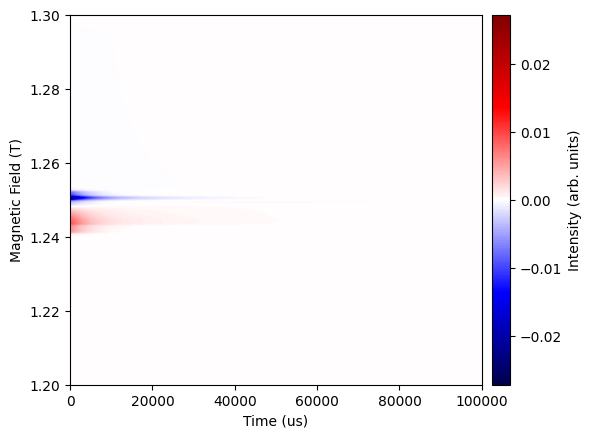

In [155]:
visualization.plot_2d_timeresolved(
    fields, time_long, out,
    time_unit="us",
)